# WindIO → OpenSG-TW: IEA-22-280 Wind Blade

**WindIO integrated with OpenSG-TW.** From the single [windIO](https://github.com/IEAWindSystems/windIO)
description of the [IEA-22-280-RWT](https://github.com/IEAWindSystems/windIO) reference blade, `OpenSG_io` and
PreVABS build the 1-D shell and 2-D solid cross-sections (section 1), and OpenSG-TW returns the Timoshenko
6×6 — comparing the **Reissner–Mindlin (RM)** and **Kirchhoff–Love (KL)** shells against the **2-D solid**.

![windIO to OpenSG workflow](_img/windio_workflow_v2.png)

**Timoshenko 6×6 — VABS `.K` order:** 1 = extension, 2–3 = transverse shear, 4 = torsion, 5–6 = bending
(so C11 = EA, C22/C33 = GA2/GA3, C44 = GJ, C55/C66 = EI2/EI3; off-diagonal Cij are the couplings).

**Span station r:** the nondimensional spanwise station (fraction of span), r = 0.2 (root) to 0.9 (tip).

**Geometry & orientation:** each cross-section outline is the blade's **OML** (outer mold line); the laminate
builds inward to the IML, and the material axes are **e2** (in-plane ply) and **e3** (wall normal, OML → IML).

In [1]:
import os, sys, time
import numpy as np
def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("OpenSG-TW repo root not found - run this notebook from inside the cloned repo")
        d = parent
CC = _find_repo_root()
for q in (CC, os.path.join(CC, "opensg_jax")):
    if q not in sys.path:
        sys.path.insert(0, q)
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import jax; jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, linewidth=170, suppress=True)
from IPython.display import Image, display
from opensg_jax.fe_jax.timo_report import sym, full_pcterr, compare_terms, nonzero_terms, wall_t, LBL
from opensg_jax.fe_jax.strip_RM import rm_timoshenko_6x6
from opensg_jax.fe_jax.gradient_kirchhoff import gradient_junction_kirchhoff
from opensg_jax.fe_jax.solid_timo import compute_timo_from_yaml
from opensg_jax.fe_jax.blade_viz import build_layup_registry, plot_layup_section, plot_orientation_montage, plot_span_loft
IB  = os.path.join(CC, "examples", "data", "iea_blade")
D2  = os.path.join(CC, "examples", "data", "2d_yaml")
IMG = os.path.join(CC, "docs", "tutorials", "_img")
STATIONS = [("r020", 0.2), ("r030", 0.3), ("r040", 0.4), ("r050", 0.5),
            ("r060", 0.6), ("r070", 0.7), ("r080", 0.8), ("r090", 0.9)]
SHELLS = [os.path.join(IB, "shell_%s.yaml" % t) for t, _ in STATIONS]
RR = [r for _, r in STATIONS]
REG = build_layup_registry(SHELLS)                       # global layup colour registry (same ply-stack -> same colour)
def rm_kl_solid(tag):
    shell = os.path.join(IB, "shell_%s.yaml" % tag)
    S = sym(np.loadtxt(os.path.join(IB, "C6_solid_%s.txt" % tag)))
    T = wall_t(shell)
    RM = sym(rm_timoshenko_6x6(shell, 0.0, dshift=T / 2, curved=False, shear="mitc_both", orient=False))
    KL = sym(gradient_junction_kirchhoff(shell, frac=0.0, dshift=T / 2, orient=False)[0])
    return S, RM, KL
print("ready | jax", jax.__version__, "| stations:", [t for t, _ in STATIONS], "| layups:", REG[1])

ready | jax 0.9.2 | stations: ['r020', 'r030', 'r040', 'r050', 'r060', 'r070', 'r080', 'r090'] | layups: ['layup 1', 'layup 2', 'layup 3', 'layup 4']


## 1 · How the cross-sections were created (windIO → OpenSG)

The 1-D shell SG YAMLs are generated **live** from the source [windIO](https://github.com/IEAWindSystems/windIO) blade file with the vendored [OpenSG_io](https://github.com/bagla0/OpenSG_io) converter — `load_blade` → `build_cross_section(r)` → `emit_opensg_yaml`, once per span station. The 2-D solid SG YAMLs add a **PreVABS** meshing step (`emit_prevabs` → `prevabs --vabs --hm` → `convert_sg_to_yaml`; that binary step is committed). The sections below read the bundled YAMLs from `examples/data/`.

In [2]:
sys.path.insert(0, os.path.join(CC, "third_party", "OpenSG_io"))
from opensg_io import load_blade, build_cross_section, emit_opensg_yaml
import yaml
WINDIO = os.path.join(CC, "examples", "data", "windio", "IEA-22-280-RWT.yaml")     # the windIO blade file
GEN = os.path.join(CC, "docs", "tutorials", "_gen"); os.makedirs(GEN, exist_ok=True)
blade = load_blade(WINDIO)                                    # windIO v2 reader (once for the whole blade)
print("windIO -> OpenSG 1-D shell SG, one cross-section per station:")
print("  %-4s %8s %8s %11s" % ("r", "chord", "elems", "laminates"))
for tag, r in STATIONS:
    cs = build_cross_section(blade, r=r, mesh_size=0.01)      # resolve laminates + webs at this station
    emit_opensg_yaml(cs, os.path.join(GEN, "shell_%s.yaml" % tag))
    d = yaml.safe_load(open(os.path.join(GEN, "shell_%s.yaml" % tag)))
    print("  %-4.1f %8.3f %8d %11d" % (r, cs["chord"], len(d["elements"]), len(d["sets"]["element"])))
print("\nThese reproduce the bundled examples/data/iea_blade/shell_*.yaml used below.")

windIO -> OpenSG 1-D shell SG, one cross-section per station:
  r       chord    elems   laminates


  0.2     7.200      315           6


  0.3     6.703      303           6


  0.4     5.834      294           6


  0.5     4.861      277           6


  0.6     3.947      272           7


  0.7     3.181      263           6


  0.8     2.584      258           6


  0.9     2.065      254           6

These reproduce the bundled examples/data/iea_blade/shell_*.yaml used below.


## 2 · Cross-section geometry, material & layup (r = 0.5)

The **2-D solid mesh** is coloured by **material** — the PreVABS mesh resolves every ply, so the through-thickness layers show (foam core, carbon spar caps, thin gelcoat / glass-triax / glass-biax plies). The **1-D shell line mesh** is coloured by **layup** (the wall laminate), with one **e2** (blue, in-plane ply) / **e3** (black, wall normal) arrow per structural region.

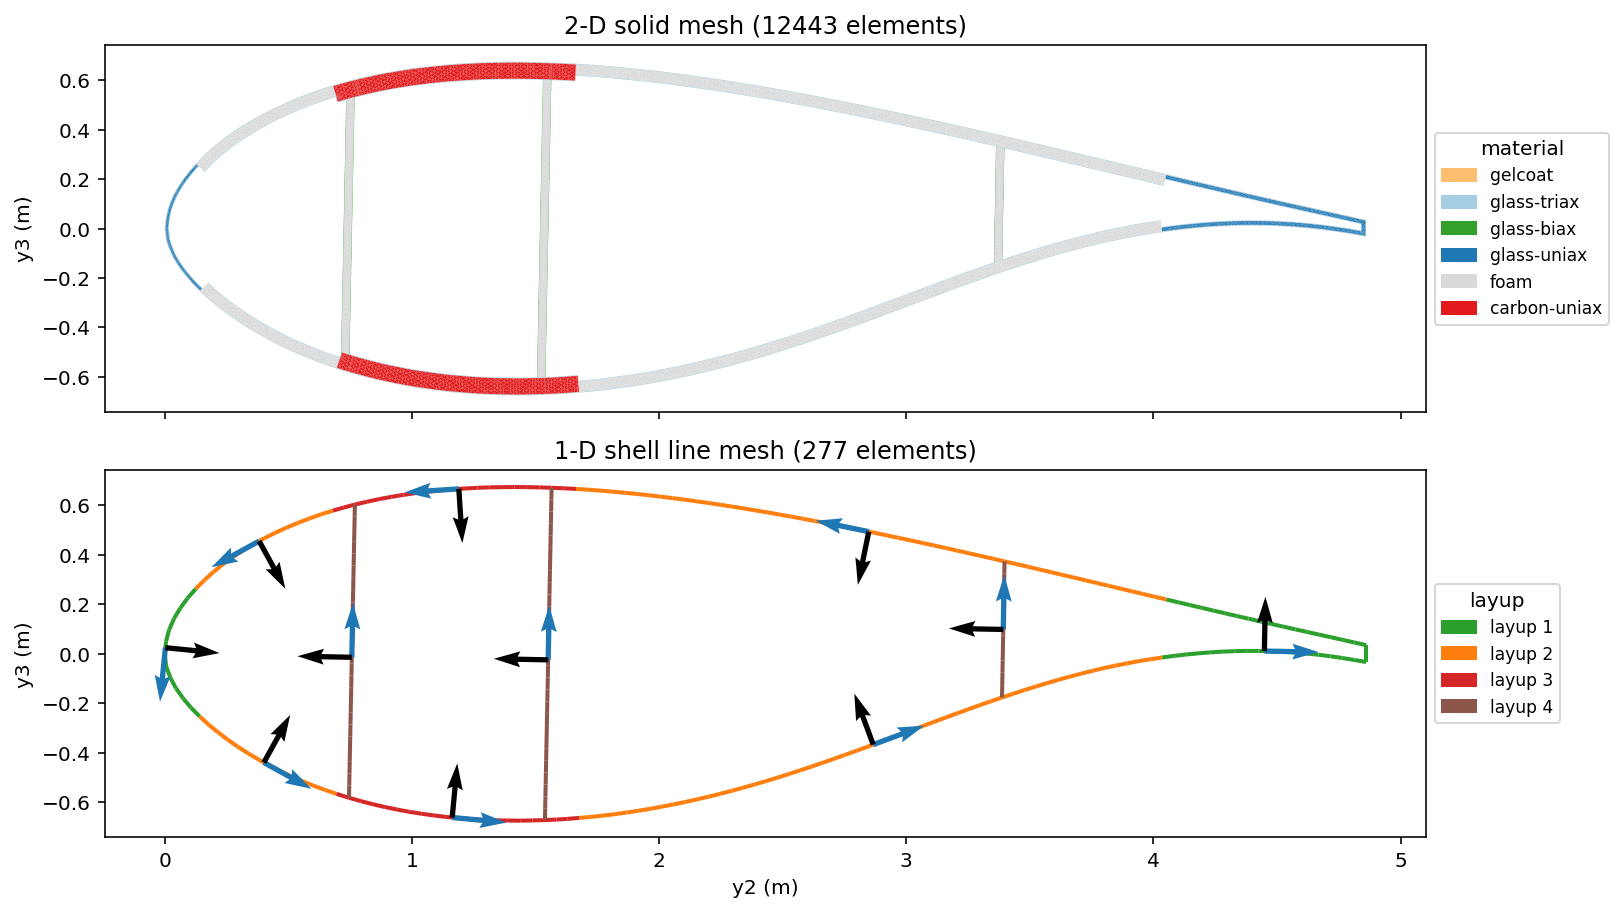

In [3]:
png = plot_layup_section(os.path.join(IB, "shell_r050.yaml"),
                         os.path.join(D2, "iea22_r050_solid.yaml"), REG,
                         os.path.join(IMG, "iea_layup_r050.png"))
Image(filename=png)

## 3 · Cross-sections lofted along the beam axis

The eight line cross-sections placed at their span stations r (isometric); the dotted black line is the beam reference axis through each section origin (red dot). The blade tapers and the carbon spar caps run out toward the tip.

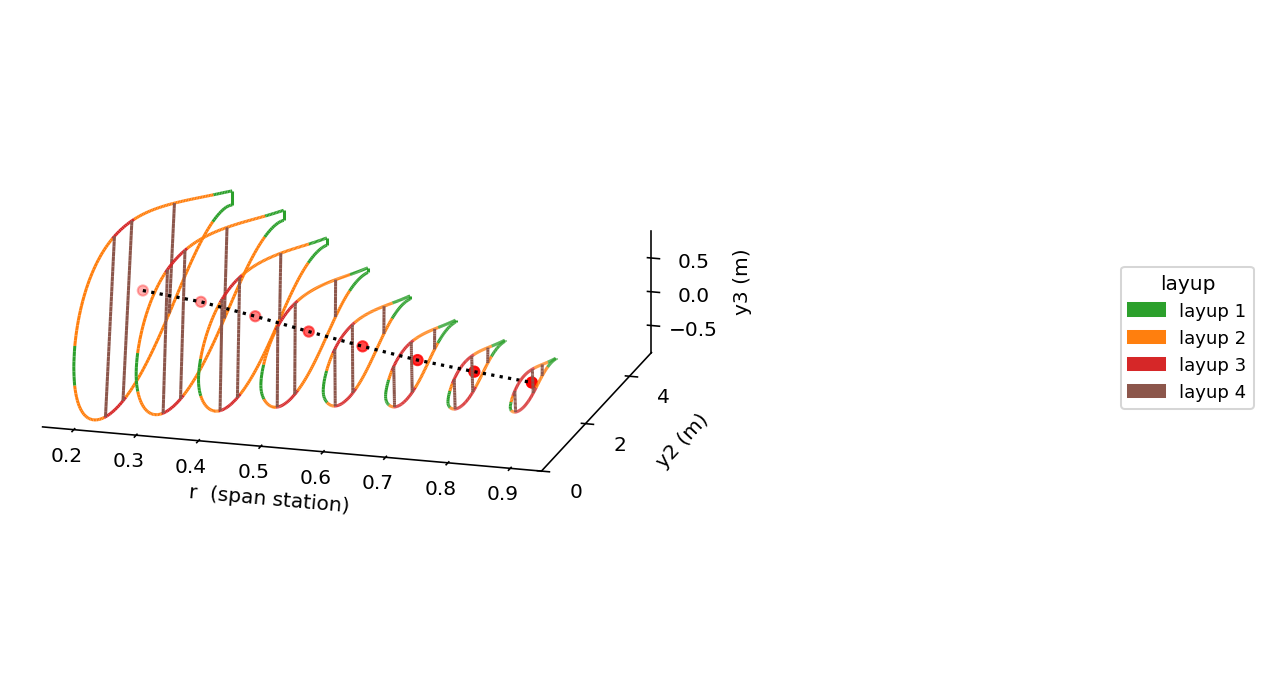

In [4]:
png = plot_span_loft(SHELLS, RR, REG, os.path.join(IMG, "iea_span_loft.png"))
Image(filename=png)

## 4 · Mid-span r = 0.5 — RM & KL vs 2-D solid

Full 6×6 for the 2-D solid, RM and KL, and the per-Cij comparison. (The full-blade solve cost is tabulated in section 7.)

In [5]:
shell = os.path.join(IB, "shell_r050.yaml"); T = wall_t(shell)
RM = sym(rm_timoshenko_6x6(shell, 0.0, dshift=T / 2, curved=False, shear="mitc_both", orient=False))
KL = sym(gradient_junction_kirchhoff(shell, frac=0.0, dshift=T / 2, orient=False)[0])
t0 = time.perf_counter()
SOL = sym(compute_timo_from_yaml(os.path.join(D2, "iea22_r050_solid.yaml"), verbose=False))
t_sol = time.perf_counter() - t0                              # 2-D solid solve time (used in the cost table)
S = sym(np.loadtxt(os.path.join(IB, "C6_solid_r050.txt")))
print("2-D solid:"); print(S)
print("\nRM (1-D shell):"); print(RM)
print("\nKL (1-D shell):"); print(KL)
print("\nr = 0.5  -  RM and KL vs the 2-D solid:")
compare_terms(S, {"RM": RM, "KL": KL})

2-D solid:
[[ 2.1520e+10  0.0000e+00  0.0000e+00  0.0000e+00  2.5900e+08 -3.0659e+10]
 [ 0.0000e+00  5.2213e+08  5.7317e+06 -1.3604e+07  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  5.7317e+06  2.0441e+08  2.3289e+08  0.0000e+00  0.0000e+00]
 [ 0.0000e+00 -1.3604e+07  2.3289e+08  7.3482e+08  0.0000e+00  0.0000e+00]
 [ 2.5900e+08  0.0000e+00  0.0000e+00  0.0000e+00  7.2552e+09 -5.9046e+08]
 [-3.0659e+10  0.0000e+00  0.0000e+00  0.0000e+00 -5.9046e+08  6.1810e+10]]

RM (1-D shell):
[[ 2.1847e+10  0.0000e+00  0.0000e+00  0.0000e+00  2.5305e+08 -3.1121e+10]
 [ 0.0000e+00  5.3538e+08  5.8303e+06 -1.4480e+07  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  5.8303e+06  2.0060e+08  2.3343e+08  0.0000e+00  0.0000e+00]
 [ 0.0000e+00 -1.4480e+07  2.3343e+08  7.7785e+08  0.0000e+00  0.0000e+00]
 [ 2.5305e+08  0.0000e+00  0.0000e+00  0.0000e+00  7.6023e+09 -5.7936e+08]
 [-3.1121e+10  0.0000e+00  0.0000e+00  0.0000e+00 -5.7936e+08  6.2958e+10]]

KL (1-D shell):
[[ 2.1847e+10 -1.4160e+03  5.4418e+02  6.9377e+02  2.

## 5 · Spanwise — transverse-shear & torsion terms vs r

The transverse-shear terms **C22 (GA2)**, **C33 (GA3)**, their coupling **C34 (GA3–GJ)** and the torsion **C44 (GJ)** across the span (**solid = RM, dotted = KL**). For the thin-walled skin both track the 2-D solid within a few %, with RM the closer of the two on the transverse-shear terms.

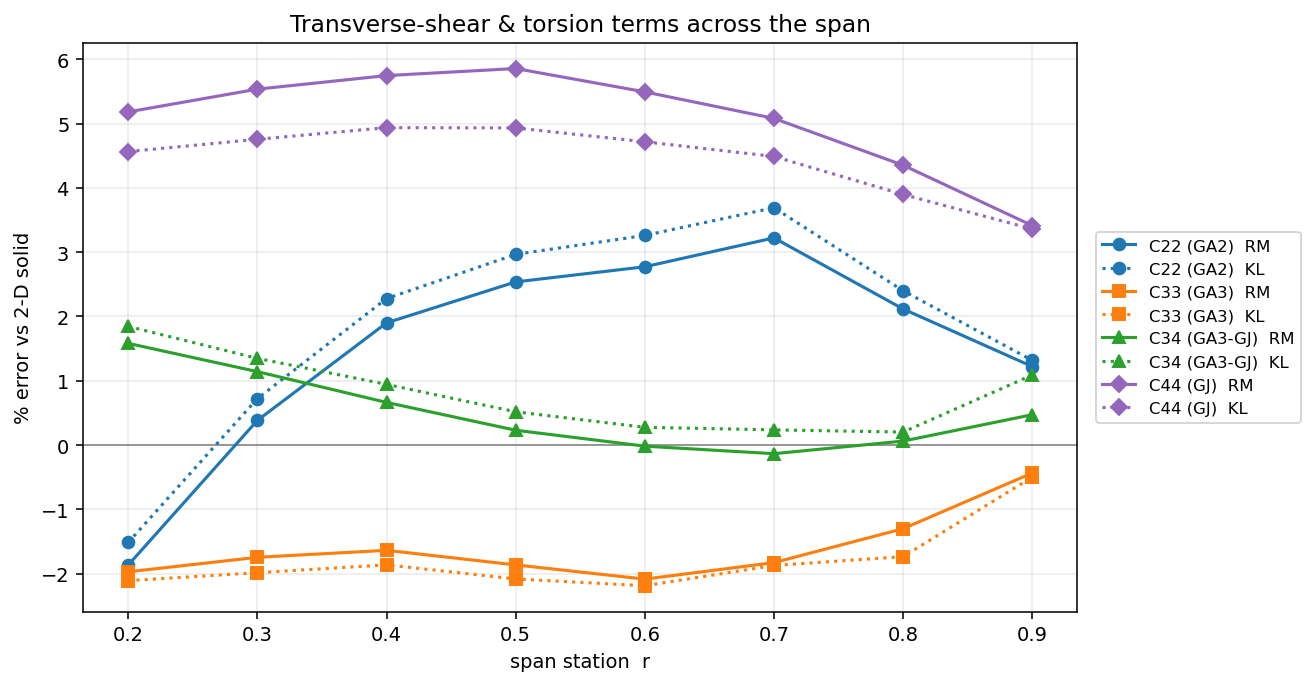

In [6]:
import matplotlib, time
matplotlib.use("Agg")
import matplotlib.pyplot as plt
# homogenize every station once; keep the 6x6 and the solve time, then plot per-term error
Cs_rm, Cs_kl, Cs_s, rm_times, kl_times = [], [], [], [], []
for tag, r in STATIONS:
    shell = os.path.join(IB, "shell_%s.yaml" % tag); T = wall_t(shell)
    S = sym(np.loadtxt(os.path.join(IB, "C6_solid_%s.txt" % tag)))
    t0 = time.perf_counter(); RM = sym(rm_timoshenko_6x6(shell, 0.0, dshift=T / 2, curved=False, shear="mitc_both", orient=False)); rm_times.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); KL = sym(gradient_junction_kirchhoff(shell, frac=0.0, dshift=T / 2, orient=False)[0]); kl_times.append(time.perf_counter() - t0)
    Cs_rm.append(RM); Cs_kl.append(KL); Cs_s.append(S)
MARK = ["o", "s", "^", "D", "v", "P"]; COL = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:red", "tab:brown"]
def term_plot(terms, png_name, title):
    fig, ax = plt.subplots(figsize=(9.5, 5))
    ax.axhline(0, color="0.5", lw=0.8)
    for k, (i, j, tag) in enumerate(terms):
        rm_e = [100.0 * (Cs_rm[s][i, j] - Cs_s[s][i, j]) / Cs_s[s][i, j] for s in range(len(STATIONS))]
        kl_e = [100.0 * (Cs_kl[s][i, j] - Cs_s[s][i, j]) / Cs_s[s][i, j] for s in range(len(STATIONS))]
        ax.plot(RR, rm_e, color=COL[k % len(COL)], marker=MARK[k % len(MARK)], ls="-", lw=1.6, label="%s  RM" % tag)
        ax.plot(RR, kl_e, color=COL[k % len(COL)], marker=MARK[k % len(MARK)], ls=":", lw=1.6, label="%s  KL" % tag)
    ax.set_xlabel("span station  r"); ax.set_ylabel("% error vs 2-D solid"); ax.set_title(title); ax.grid(alpha=0.25)
    ax.legend(fontsize=8.5, ncol=1, loc="center left", bbox_to_anchor=(1.01, 0.5))   # vertical, outside the plot
    pth = os.path.join(IMG, png_name); fig.tight_layout(); fig.savefig(pth, dpi=140, bbox_inches="tight"); plt.close(fig)
    return pth
SHEAR = [(1, 1, "C22 (GA2)"), (2, 2, "C33 (GA3)"), (2, 3, "C34 (GA3-GJ)"), (3, 3, "C44 (GJ)")]
Image(filename=term_plot(SHEAR, "iea22_blade_span.png", "Transverse-shear & torsion terms across the span"))

## 6 · Spanwise — classical stiffness terms vs r

The classical extension / bending block — **C11 (EA)**, **C55 (EI2)**, **C66 (EI3)** and their couplings **C15**, **C16**, **C56** — across the span. Both shells reproduce these to within a few % everywhere (this is the regime KL is built for).

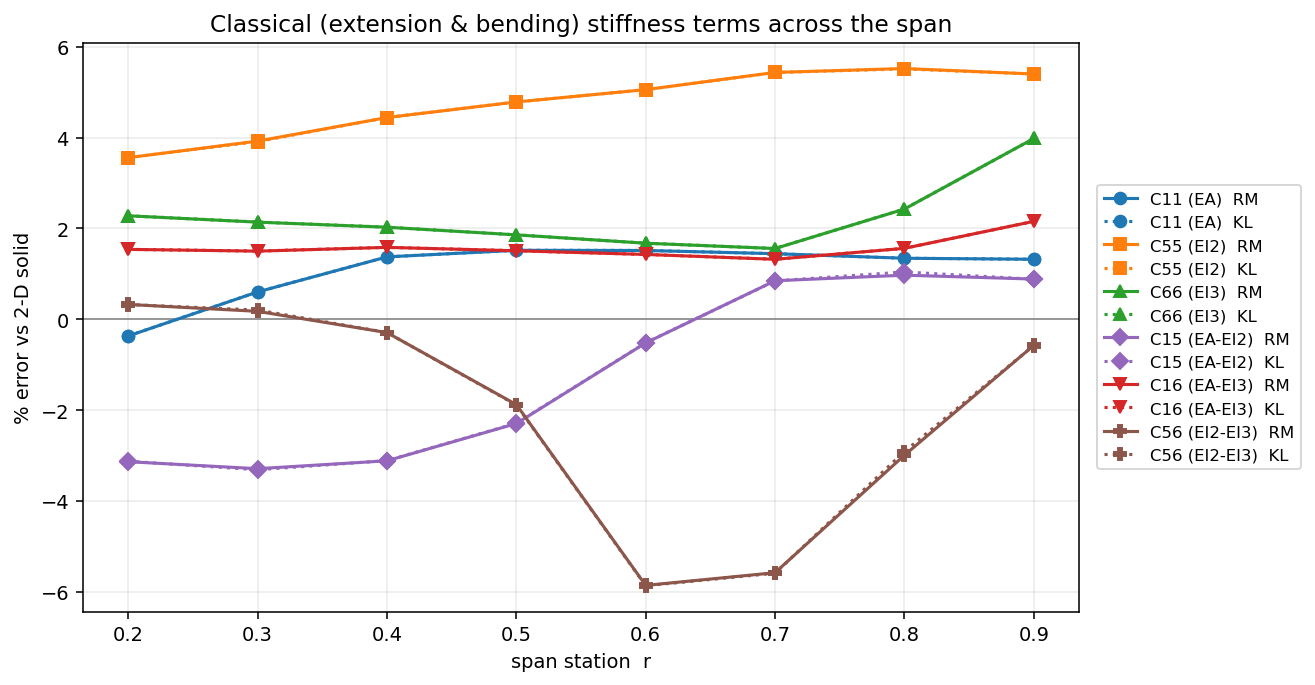

In [7]:
CLASSIC_T = [(0, 0, "C11 (EA)"), (4, 4, "C55 (EI2)"), (5, 5, "C66 (EI3)"),
             (0, 4, "C15 (EA-EI2)"), (0, 5, "C16 (EA-EI3)"), (4, 5, "C56 (EI2-EI3)")]
Image(filename=term_plot(CLASSIC_T, "iea22_blade_classic.png", "Classical (extension & bending) stiffness terms across the span"))

## 7 · Full-blade homogenization cost

Wall-clock to homogenize all eight stations with each model — the 1-D shells run the whole blade in seconds, while the 2-D solid is one finite-element solve per station.

In [8]:
rm_per = float(np.mean(rm_times[1:])); kl_per = float(np.mean(kl_times[1:]))   # mean of stations 2-8 (drop first-run compile)
rm_8 = float(np.sum(rm_times)); kl_8 = float(np.sum(kl_times))
print("Full-blade homogenization cost:")
print("  %-11s %13s %12s" % ("model", "per station", "8 stations"))
print("  %-11s %11.2f s %10.1f s" % ("RM shell", rm_per, rm_8))
print("  %-11s %11.2f s %10.1f s" % ("KL shell", kl_per, kl_8))
print("  %-11s %11.1f s %10.1f s" % ("2-D solid", t_sol, t_sol * 8))
print("\n(per station = mean over stations 2-8, excluding the first run's one-time JAX compile;")
print(" the 2-D solid is measured at r = 0.5 and scaled x8 -- only that solid mesh is bundled.)")

Full-blade homogenization cost:
  model         per station   8 stations
  RM shell           1.14 s        9.4 s
  KL shell          10.88 s       87.9 s
  2-D solid          15.8 s      126.4 s

(per station = mean over stations 2-8, excluding the first run's one-time JAX compile;
 the 2-D solid is measured at r = 0.5 and scaled x8 -- only that solid mesh is bundled.)


## Takeaway

For the thin-walled blade skin both shell models track the 2-D solid closely on the full 6×6, with **RM the better of the two on the transverse-shear terms** at every station — and at a fraction of the cost (RM ≈ 1 s, KL ≈ 3 s vs ≈ 15 s for the 2-D solid). Run the RM shell at every station to assemble the blade's 1-D beam model.